In [1]:
!pip install -q monai nibabel einops torch torchvision matplotlib tqdm

In [2]:
import cv2
import tensorboard
import numpy

print("cv2 OK")
print("tensorboard OK")
print("numpy:", numpy.__version__)

cv2 OK
tensorboard OK
numpy: 1.26.4


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from monai.networks.nets import SwinUNETR
from einops import rearrange
from scipy.stats import entropy

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SwinUNETR(
    in_channels=3,
    out_channels=2,      
    feature_size=12,
    use_checkpoint=False
).to(device)

model.load_state_dict(
    torch.load("/Users/apple/Desktop/BRAINIAC/models/best_swin_unetr.pt",
               map_location=device)
)

model.eval()
print("✅ Model loaded successfully")

✅ Model loaded successfully


In [5]:
attention_maps = []

def attention_hook(module, input, output):
    attention_maps.append(output.detach().cpu())

for stage in [
    model.swinViT.layers1,
    model.swinViT.layers2,
    model.swinViT.layers3,
    model.swinViT.layers4,
]:
    for layer in stage:
        for block in layer.blocks:
            block.attn.softmax.register_forward_hook(attention_hook)

print("✅ Hooks registered successfully")

✅ Hooks registered successfully


In [6]:
import cv2
import torch
import numpy as np

def load_sample(path):

    # read image
    x = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    # resize if needed (match training size)
    x = cv2.resize(x, (224,224))

    # normalize
    x = x / 255.0

    # convert to tensor
    x = torch.tensor(x).unsqueeze(0).unsqueeze(0).float()

    return x

In [11]:
import cv2
import torch
import numpy as np

def load_sample(path):

    x = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if x is None:
        raise ValueError("Image not found")

    # Resize to SwinUNETR-safe size
    x = cv2.resize(x, (256,256))
    x = x / 255.0

    # Create 3 channels
    x = np.stack([x,x,x], axis=0)   # (3, H, W)

    # Create fake 32-slice volume
    x = np.stack([x]*32, axis=1)    # (3, 32, H, W)

    # Convert to tensor
    x = torch.tensor(x).unsqueeze(0).float()  # (1,3,32,256,256)

    return x

In [8]:
import torch
import torch.nn.functional as F

def compute_attention_entropy(attn_maps):
    entropies = []

    for attn in attn_maps:
        # Flatten spatial attention
        p = attn.flatten()
        
        # Normalize into probability distribution
        p = p / (p.sum() + 1e-8)
        
        # Compute entropy
        entropy = -torch.sum(p * torch.log(p + 1e-8))
        entropies.append(entropy)

    return torch.mean(torch.stack(entropies)).item()

In [12]:
x = load_sample("/Users/apple/Desktop/BRAINIAC/data/raw/no_tumor/image(10).jpg").to(device)
print(x.shape)

torch.Size([1, 3, 32, 256, 256])


In [13]:
attention_maps.clear()

with torch.no_grad():
    y_hat = model(x)

print("Output shape:", y_hat.shape)
print("Collected attention maps:", len(attention_maps))

Output shape: torch.Size([1, 2, 32, 256, 256])
Collected attention maps: 8


In [14]:
def tokens_to_spatial(attn):
    """
    Convert Swin window attention → ONE spatial map per image.
    """

    if attn.ndim != 4:
        return None

    B, H, T, _ = attn.shape

    attn = attn.mean(dim=1)      
    attn = attn.mean(dim=-1)     

    window_tokens = 343

    if T % window_tokens != 0:
        return None

    num_windows = T // window_tokens

    attn = attn.view(B, num_windows, 7, 7, 7)

    
    attn = attn.mean(dim=1)   #7]

    attn = torch.nn.functional.interpolate(
        attn.unsqueeze(1),
        size=(128,128,128),
        mode="trilinear",
        align_corners=False
    ).squeeze(1)

    return attn

spatial_maps = []
for attn in attention_maps:
    m = tokens_to_spatial(attn)
    if m is not None:
        spatial_maps.append(m)

if len(spatial_maps) == 0:
    raise RuntimeError("❌ No valid attention maps captured — run inference again after registering hooks")

if len(spatial_maps) == 0:
    raise RuntimeError("❌ No valid attention maps — run inference again")

spatial_maps = [m for m in spatial_maps if m.shape == spatial_maps[0].shape]

final_attention = torch.mean(torch.stack(spatial_maps), dim=0)

attention_entropy = compute_attention_entropy([final_attention])
print("✅ Attention Entropy:", attention_entropy)

✅ Attention Entropy: 18.377574920654297


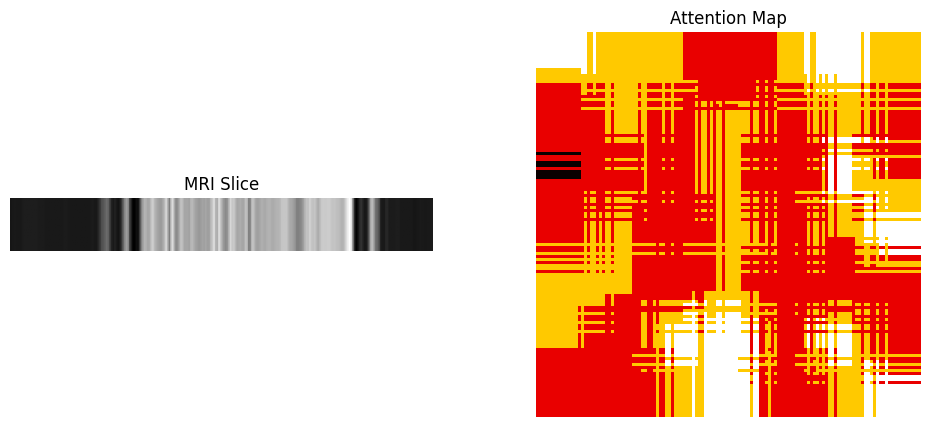

In [15]:
slice_idx = 64

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("MRI Slice")
plt.imshow(x[0,0,:,:,slice_idx].cpu(), cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Attention Map")
plt.imshow(final_attention[0,:,:,slice_idx].cpu(), cmap="hot")
plt.axis("off")

plt.show()